In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datafusion24-churn/currency_rk.csv
/kaggle/input/datafusion24-churn/report_dates.csv
/kaggle/input/datafusion24-churn/mcc_codes.csv
/kaggle/input/datafusion24-churn/clients.csv
/kaggle/input/datafusion24-churn/train.csv
/kaggle/input/datafusion24-churn/sample_submit_naive.csv
/kaggle/input/datafusion24-churn/transactions.csv/transactions.csv


# Libraries

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    rc={
        "axes.facecolor": "#f7f7f9",      # светло-бело-серый фон
        "figure.facecolor": "#f7f7f9",

        "grid.color": "#e6e6eb",           # очень мягкая сетка
        "grid.linewidth": 0.6,

        "axes.edgecolor": "#dddddd",
        "axes.labelcolor": "#444444",
        "xtick.color": "#555555",
        "ytick.color": "#555555",

        "text.color": "#333333",

        "axes.titleweight": "bold",
        "axes.titlesize": 14,
        "axes.labelsize": 12,
    }
)

# Нежно-розовая палитра
pink_palette = ["#f4b6c2", "#f7c6d0", "#f2a1b3", "#f9d5dc"]
sns.set_palette(pink_palette)


In [3]:
from scipy.stats import fisher_exact
from scipy.stats import chi2_contingency

In [4]:
transactions = pd.read_csv('/kaggle/input/datafusion24-churn/transactions.csv/transactions.csv')
clients = pd.read_csv('/kaggle/input/datafusion24-churn/clients.csv')
currency = pd.read_csv('/kaggle/input/datafusion24-churn/currency_rk.csv')
mcc_codes = pd.read_csv('/kaggle/input/datafusion24-churn/mcc_codes.csv')
reports = pd.read_csv('/kaggle/input/datafusion24-churn/report_dates.csv')
df = pd.read_csv('/kaggle/input/datafusion24-churn/train.csv')

In [5]:
df.head()

,user_id,target,time
0,3,0,77
1,13,0,86
2,37,0,89
3,41,0,57
4,42,0,84


# all datasets heads

In [6]:
transactions.head()

,user_id,mcc_code,currency_rk,transaction_amt,transaction_dttm
0,3,3,1,-183.883957,2022-01-28 12:05:33
1,3,3,1,-3206.437012,2022-01-28 12:52:30
2,3,16,1,-153866.890625,2022-02-16 14:45:56
3,3,56,1,-15144.601562,2022-03-09 19:58:29
4,3,0,1,5297.908691,2022-03-12 18:11:31


In [7]:
clients.head()

,user_id,report,employee_count_nm,bankemplstatus,customer_age
0,3,2,ОТ 101 ДО 500,0,3
1,9,1,БОЛЕЕ 1001,0,3
2,13,6,ОТ 501 ДО 1000,0,2
3,37,5,БОЛЕЕ 1001,0,2
4,41,1,ОТ 101 ДО 500,0,2


In [8]:
currency.head()

,currency_rk,Name
0,48,RUR
1,50,USD
2,60,EUR


In [9]:
mcc_codes.head()

,MCC,Название,Описание
0,742,Ветеринарные услуги,Лицензированные специалисты в основном занимаю...
1,763,Сельскохозяйственные кооперативы,"Ассоциации и кооперативы, которые предоставляю..."
2,780,Услуги садоводства и ландшафтного дизайна,Ландшафтные архитекторы и другие поставщики ус...
3,1520,Генеральные подрядчики – жилое и коммерческое ...,"Генеральные подрядчики, в основном занимающиес..."
4,1711,"Генеральные подрядчики по вентиляции, теплосна...","Специальные торговые подрядчики, которые работ..."


In [10]:
reports.head()

,report,report_dt
0,1,2022-07-31 03:00:00
1,2,2022-08-31 03:00:00
2,3,2022-09-30 03:00:00
3,4,2022-10-31 03:00:00
4,5,2022-11-30 03:00:00


In [11]:
df.head()

,user_id,target,time
0,3,0,77
1,13,0,86
2,37,0,89
3,41,0,57
4,42,0,84


# ignore this part

In [12]:
mcc_codes.head()

,MCC,Название,Описание
0,742,Ветеринарные услуги,Лицензированные специалисты в основном занимаю...
1,763,Сельскохозяйственные кооперативы,"Ассоциации и кооперативы, которые предоставляю..."
2,780,Услуги садоводства и ландшафтного дизайна,Ландшафтные архитекторы и другие поставщики ус...
3,1520,Генеральные подрядчики – жилое и коммерческое ...,"Генеральные подрядчики, в основном занимающиес..."
4,1711,"Генеральные подрядчики по вентиляции, теплосна...","Специальные торговые подрядчики, которые работ..."


In [13]:
mcc_codes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 385 entries, 0 to 384
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   MCC       385 non-null    int64 
 1   Название  385 non-null    object
 2   Описание  290 non-null    object
dtypes: int64(1), object(2)
memory usage: 9.2+ KB


In [14]:
mcc_codes['MCC'].nunique()

385

In [15]:
clients.head()

,user_id,report,employee_count_nm,bankemplstatus,customer_age
0,3,2,ОТ 101 ДО 500,0,3
1,9,1,БОЛЕЕ 1001,0,3
2,13,6,ОТ 501 ДО 1000,0,2
3,37,5,БОЛЕЕ 1001,0,2
4,41,1,ОТ 101 ДО 500,0,2


In [16]:
clients['user_id'].nunique()

96000

In [17]:
clients['bankemplstatus'].value_counts()

bankemplstatus
0    95687
1      313
Name: count, dtype: int64

In [18]:
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96000 entries, 0 to 95999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            96000 non-null  int64 
 1   report             96000 non-null  int64 
 2   employee_count_nm  59534 non-null  object
 3   bankemplstatus     96000 non-null  int64 
 4   customer_age       96000 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 3.7+ MB


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   user_id  64000 non-null  int64
 1   target   64000 non-null  int64
 2   time     64000 non-null  int64
dtypes: int64(3)
memory usage: 1.5 MB


In [20]:
data = df.merge(
    clients,
    on='user_id',
    how='inner'
)

In [21]:
data.head()

,user_id,target,time,report,employee_count_nm,bankemplstatus,customer_age
0,3,0,77,2,ОТ 101 ДО 500,0,3
1,13,0,86,6,ОТ 501 ДО 1000,0,2
2,37,0,89,5,БОЛЕЕ 1001,0,2
3,41,0,57,1,ОТ 101 ДО 500,0,2
4,42,0,84,12,ДО 10,0,3


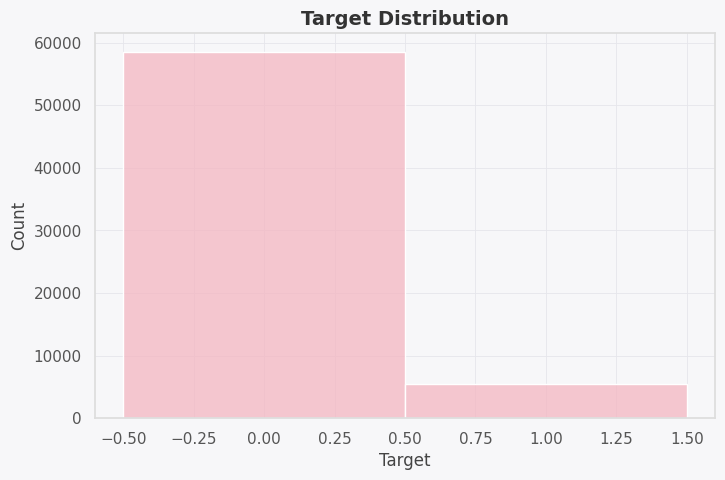

In [22]:
plt.figure(figsize = (8, 5))
sns.histplot(data, x='target', discrete=True)
plt.title('Target Distribution')
plt.xlabel('Target')

plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
data['target'].value_counts()

target
0    58583
1     5417
Name: count, dtype: int64

In [24]:
data['target'].value_counts(normalize=True) * 100

target
0    91.535938
1     8.464062
Name: proportion, dtype: float64

With approximately 8.5% of observations belonging to the minority class, the problem is appropriately formulated as a binary classification task with class imbalance, rather than as an anomaly detection problem.

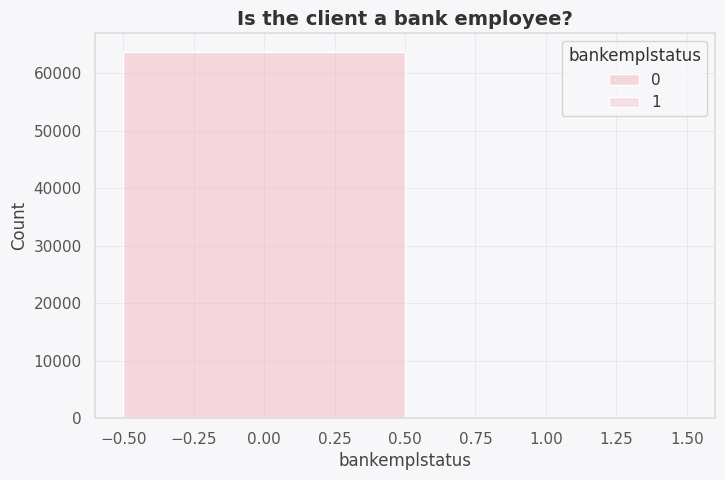

In [25]:
plt.figure(figsize = (8, 5))
sns.histplot(data, x='bankemplstatus', hue='bankemplstatus', discrete=True,  legend=True)
plt.title('Is the client a bank employee?')

plt.savefig('bank_employee.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
data['bankemplstatus'].value_counts(normalize=True)*100

bankemplstatus
0    99.678125
1     0.321875
Name: proportion, dtype: float64

In [27]:
data[data['bankemplstatus'] == 1].target.value_counts()

target
0    205
1      1
Name: count, dtype: int64

In [28]:
data[data['bankemplstatus'] == 1].target.value_counts(normalize=True)*100

target
0    99.514563
1     0.485437
Name: proportion, dtype: float64

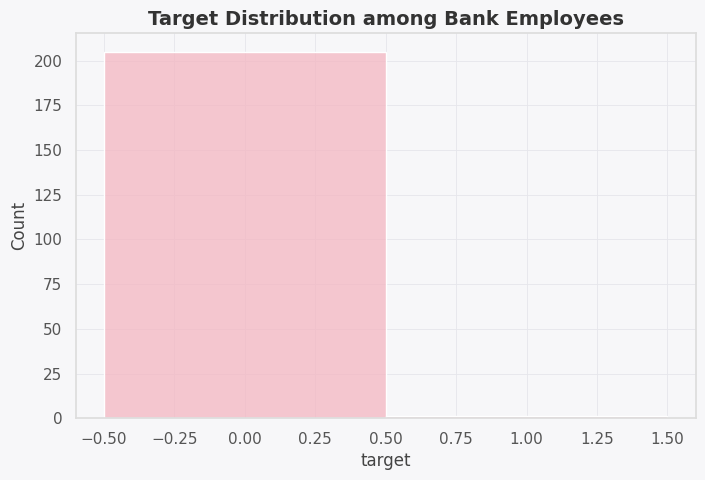

In [29]:
plt.figure(figsize = (8, 5))
sns.histplot(data[data['bankemplstatus'] == 1], x='target', discrete=True)
plt.title('Target Distribution among Bank Employees')

plt.savefig('bank_employee_target.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
table = (
    data[data['bankemplstatus'] == 1]
    .target
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

table.columns = ['Target', 'Percentage (%)']
table


,Target,Percentage (%)
0,0,99.51
1,1,0.49


In [31]:
contingency = pd.crosstab(
    data['bankemplstatus'],
    data['target']
)

contingency

target,0,1
bankemplstatus,,
0,58378,5416
1,205,1


In [32]:
oddsratio, p_value = fisher_exact(contingency)

oddsratio, p_value

(np.float64(0.05257952948805707), np.float64(4.6323008218406876e-07))

----

-----

# EDA

## target

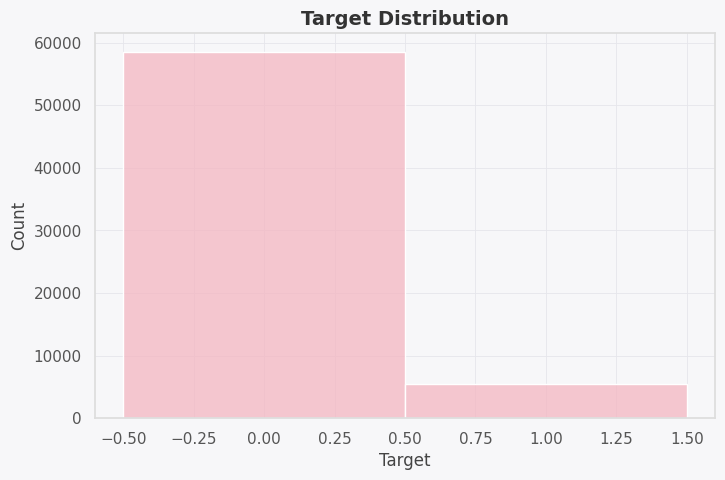

In [33]:
plt.figure(figsize = (8, 5))
sns.histplot(data, x='target', discrete=True)
plt.title('Target Distribution')
plt.xlabel('Target')

plt.show()

In [34]:
df['target'].value_counts()

target
0    58583
1     5417
Name: count, dtype: int64

In [35]:
df['target'].value_counts(normalize=True)*100

target
0    91.535938
1     8.464062
Name: proportion, dtype: float64

## time 

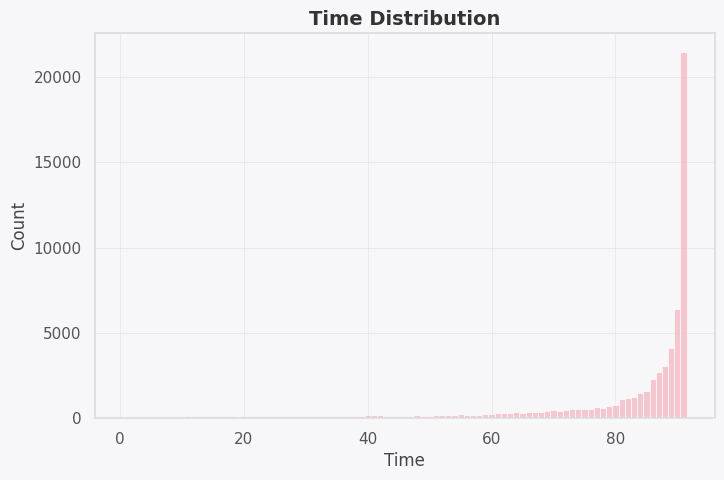

In [36]:
plt.figure(figsize = (8, 5))
sns.histplot(data, x='time', discrete=True)
plt.title('Time Distribution')
plt.xlabel('Time')

plt.savefig('time_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [37]:
df[['target', 'time']].describe()

,target,time
count,64000.000000,64000.000000
mean,0.084641,79.898734
std,0.278348,18.749371
min,0.000000,1.000000
25%,0.000000,79.000000
50%,0.000000,89.000000
75%,0.000000,91.000000
max,1.000000,91.000000


In [38]:
df[df['target'] == 1].describe()

,user_id,target,time
count,5417.000000,5417.0,5417.000000
mean,356637.015507,1.0,50.235186
std,158737.483811,0.0,25.911487
min,100.000000,1.0,1.000000
25%,242514.000000,1.0,28.000000
50%,400885.000000,1.0,51.000000
75%,496892.000000,1.0,73.000000
max,561018.000000,1.0,91.000000


In [39]:
df[df['target'] == 0].describe()

,user_id,target,time
count,58583.000000,58583.0,58583.000000
mean,268972.985218,0.0,82.641637
std,157704.913033,0.0,15.267073
min,3.000000,0.0,1.000000
25%,131692.500000,0.0,82.000000
50%,268010.000000,0.0,89.000000
75%,403631.000000,0.0,91.000000
max,562740.000000,0.0,91.000000


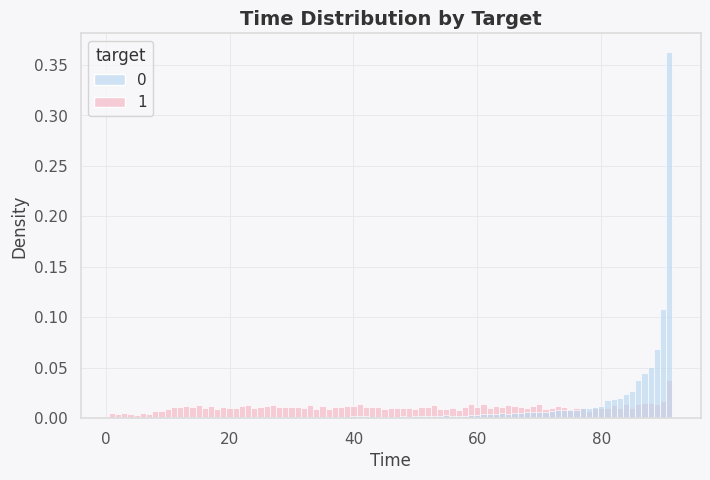

In [40]:
target_palette = {
    0: "#b8d8f0",  # нежно-голубой
    1: "#f4b6c2",  # нежно-розовый
}


plt.figure(figsize=(8, 5))

sns.histplot(
    data=data,
    x='time',
    hue='target',
    discrete=True,
    stat='density',
    common_norm=False,
    alpha=0.65,
    palette=target_palette
)

plt.title('Time Distribution by Target')
plt.xlabel('Time')
plt.ylabel('Density')

plt.savefig('time_distribution_by_target.png', dpi=300, bbox_inches='tight')
plt.show()


In [41]:
reports

,report,report_dt
0,1,2022-07-31 03:00:00
1,2,2022-08-31 03:00:00
2,3,2022-09-30 03:00:00
3,4,2022-10-31 03:00:00
4,5,2022-11-30 03:00:00
5,6,2022-12-31 03:00:00
6,7,2023-01-31 03:00:00
7,8,2023-02-28 03:00:00
8,9,2023-03-31 03:00:00
9,10,2023-04-30 03:00:00


In [42]:
reports['report'].nunique()

12

In [43]:
df.head()

,user_id,target,time
0,3,0,77
1,13,0,86
2,37,0,89
3,41,0,57
4,42,0,84


In [44]:
clients.head()

,user_id,report,employee_count_nm,bankemplstatus,customer_age
0,3,2,ОТ 101 ДО 500,0,3
1,9,1,БОЛЕЕ 1001,0,3
2,13,6,ОТ 501 ДО 1000,0,2
3,37,5,БОЛЕЕ 1001,0,2
4,41,1,ОТ 101 ДО 500,0,2


In [45]:
data.head()

,user_id,target,time,report,employee_count_nm,bankemplstatus,customer_age
0,3,0,77,2,ОТ 101 ДО 500,0,3
1,13,0,86,6,ОТ 501 ДО 1000,0,2
2,37,0,89,5,БОЛЕЕ 1001,0,2
3,41,0,57,1,ОТ 101 ДО 500,0,2
4,42,0,84,12,ДО 10,0,3


In [46]:
report_stat = data.groupby('report')['time'].describe()

In [47]:
report_stat

,count,mean,std,min,25%,50%,75%,max
report,,,,,,,,
1,4997.0,81.476086,16.805976,1.0,80.0,89.0,91.0,91.0
2,5088.0,80.132665,18.084372,2.0,79.0,89.0,91.0,91.0
3,5182.0,78.345812,20.597138,1.0,77.0,88.0,91.0,91.0
4,5313.0,80.154338,18.723472,1.0,79.0,89.0,91.0,91.0
5,5290.0,79.971078,18.859816,1.0,80.0,89.0,91.0,91.0
6,5335.0,79.209747,19.327542,1.0,78.0,88.0,91.0,91.0
7,5381.0,78.837577,19.614349,1.0,76.0,88.0,91.0,91.0
8,5360.0,79.470149,19.513103,1.0,78.0,89.0,91.0,91.0
9,5467.0,80.582404,18.139031,1.0,80.0,89.0,91.0,91.0


# customer_age

In [48]:
data['customer_age'].nunique()

4

In [49]:
data['customer_age'].describe()

count    64000.000000
mean         1.613656
std          1.178099
min          0.000000
25%          0.000000
50%          2.000000
75%          3.000000
max          3.000000
Name: customer_age, dtype: float64

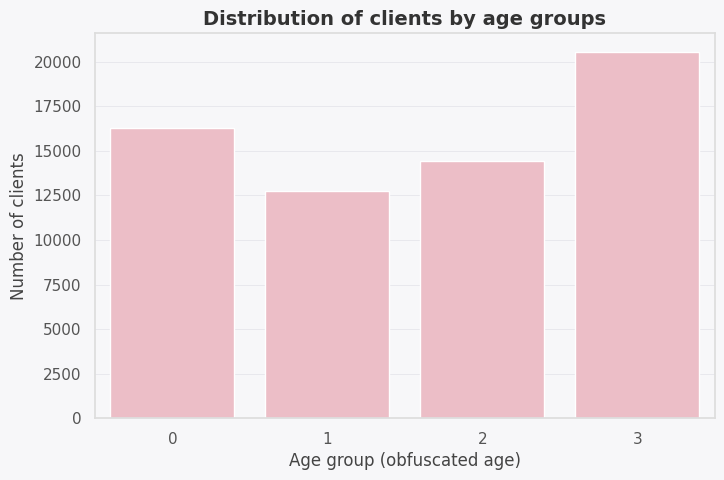

In [50]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x=data['customer_age'].value_counts().sort_index().index,
    y=data['customer_age'].value_counts().sort_index().values
)

plt.title('Distribution of clients by age groups')
plt.xlabel('Age group (obfuscated age)')
plt.ylabel('Number of clients')

plt.savefig('distribution_age.png', dpi=300, bbox_inches='tight')
plt.show()

In [51]:
data['customer_age'].value_counts().sort_index()

customer_age
0    16262
1    12766
2    14408
3    20564
Name: count, dtype: int64

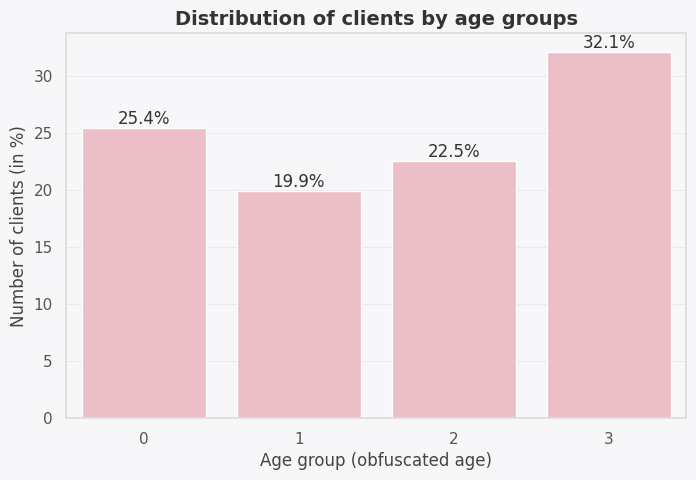

In [52]:
plt.figure(figsize=(8, 5))

values = data['customer_age'].value_counts(normalize=True).sort_index().values * 100
categories = data['customer_age'].value_counts(normalize=True).sort_index().index

ax = sns.barplot(
    x=categories,
    y=values
)

plt.title('Distribution of clients by age groups')
plt.xlabel('Age group (obfuscated age)')
plt.ylabel('Number of clients (in %)')

# подписи над столбцами
for i, v in enumerate(values):
    ax.text(
        i,
        v,
        f'{v:.1f}%',
        ha='center',
        va='bottom'
    )

plt.savefig('distribution_age_percentage.png', dpi=300, bbox_inches='tight')
plt.show()


In [53]:
data['customer_age'].value_counts().sort_index()

customer_age
0    16262
1    12766
2    14408
3    20564
Name: count, dtype: int64

In [54]:
data[data['target'] == 1]['customer_age'].value_counts().sort_index()

customer_age
0    2474
1     779
2     840
3    1324
Name: count, dtype: int64

In [55]:
data[data['target'] == 0]['customer_age'].value_counts().sort_index()

customer_age
0    13788
1    11987
2    13568
3    19240
Name: count, dtype: int64

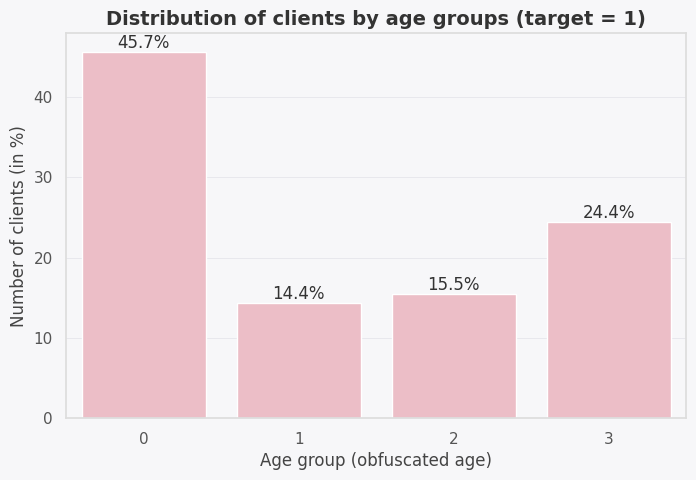

In [56]:
plt.figure(figsize=(8, 5))

values = data[data['target'] == 1]['customer_age'].value_counts(normalize=True).sort_index().values * 100
categories = data[data['target'] == 1]['customer_age'].value_counts(normalize=True).sort_index().index

ax = sns.barplot(
    x=categories,
    y=values
)

plt.title('Distribution of clients by age groups (target = 1)')
plt.xlabel('Age group (obfuscated age)')
plt.ylabel('Number of clients (in %)')

# подписи над столбцами
for i, v in enumerate(values):
    ax.text(
        i,
        v,
        f'{v:.1f}%',
        ha='center',
        va='bottom'
    )

plt.savefig('distribution_age_percentage_targettrue.png', dpi=300, bbox_inches='tight')
plt.show()

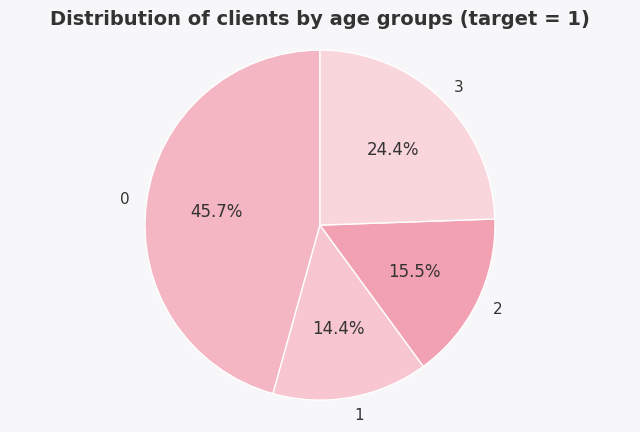

In [57]:
values = (
    data[data['target'] == 1]['customer_age']
    .value_counts(normalize=True)
    .sort_index()
    .values * 100
)

labels = (
    data[data['target'] == 1]['customer_age']
    .value_counts(normalize=True)
    .sort_index()
    .index
)

plt.figure(figsize=(8, 5))

plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of clients by age groups (target = 1)')
plt.axis('equal')  # чтобы был ровный круг

plt.savefig('distribution_age_percentage_targettrue_pie.png', dpi=300, bbox_inches='tight')
plt.show()


In [58]:
base_share = (
    data['customer_age']
    .value_counts(normalize=True)
    .sort_index()
)

base_share


customer_age
0    0.254094
1    0.199469
2    0.225125
3    0.321313
Name: proportion, dtype: float64

In [59]:
base_share.loc[0] #Доля нулевой группы в клиентской базе

np.float64(0.25409375)

In [60]:
churn_share = (
    data[data['target'] == 1]['customer_age']
    .value_counts(normalize=True)
    .sort_index()
)

churn_share

customer_age
0    0.456710
1    0.143807
2    0.155067
3    0.244416
Name: proportion, dtype: float64

In [61]:
churn_share.loc[0] #Доля нулевой группы среди ушедших клиентов

np.float64(0.456710356285767)

In [62]:
contingency = pd.crosstab(data['customer_age'], data['target'])
contingency


target,0,1
customer_age,,
0,13788,2474
1,11987,779
2,13568,840
3,19240,1324


In [63]:
chi2, p_value, dof, expected = chi2_contingency(contingency)

chi2, p_value

(np.float64(1285.9908369907341), np.float64(1.612627924635956e-278))

In [64]:
print(f'{p_value:.300f}')

0.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000016126279246359560698034


In [65]:
data['is_young'] = (data['customer_age'] == 0).astype(int)

contingency_binary = pd.crosstab(data['is_young'], data['target'])
contingency_binary

target,0,1
is_young,,
0,44795,2943
1,13788,2474


In [66]:
chi2, p_value, *_ = chi2_contingency(contingency_binary)
p_value

np.float64(1.7785201918707426e-280)

In [67]:
print(f'{p_value:.300f}')

0.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000177852019187074263268


## employee_count_nm  

In [68]:
data

,user_id,target,time,report,employee_count_nm,bankemplstatus,customer_age,is_young
0,3,0,77,2,ОТ 101 ДО 500,0,3,0
1,13,0,86,6,ОТ 501 ДО 1000,0,2,0
2,37,0,89,5,БОЛЕЕ 1001,0,2,0
3,41,0,57,1,ОТ 101 ДО 500,0,2,0
4,42,0,84,12,ДО 10,0,3,0
...,...,...,...,...,...,...,...,...
63995,561824,0,91,12,NaN,0,0,1
63996,562043,0,75,12,NaN,0,2,0
63997,562312,0,91,12,NaN,0,0,1
63998,562721,0,29,12,NaN,0,2,0


In [69]:
data['employee_count_nm'].count()

np.int64(39777)

In [70]:
data['employee_count_nm'].isnull().sum()

np.int64(24223)

In [71]:
print((data['employee_count_nm'].isnull().sum() / data['employee_count_nm'].count()) * 100, '%')

60.89700077934484 %


In [72]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            64000 non-null  int64 
 1   target             64000 non-null  int64 
 2   time               64000 non-null  int64 
 3   report             64000 non-null  int64 
 4   employee_count_nm  39777 non-null  object
 5   bankemplstatus     64000 non-null  int64 
 6   customer_age       64000 non-null  int64 
 7   is_young           64000 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 3.9+ MB


In [73]:
data['employee_count_nm'].head()

0     ОТ 101 ДО 500
1    ОТ 501 ДО 1000
2        БОЛЕЕ 1001
3     ОТ 101 ДО 500
4             ДО 10
Name: employee_count_nm, dtype: object

In [74]:
data['employee_count_nm'].nunique()

9

In [75]:
data['employee_count_nm'].unique()

array(['ОТ 101 ДО 500', 'ОТ 501 ДО 1000', 'БОЛЕЕ 1001', 'ДО 10', nan,
       'ОТ 11 ДО 50', 'ОТ 51 ДО 100', 'ОТ 31 ДО 50', 'БОЛЕЕ 500',
       'ОТ 11 ДО 30'], dtype=object)

In [76]:
data['employee_count_missing'] = data['employee_count_nm'].isna().astype(int)

pd.crosstab(data['employee_count_missing'], data['target'], normalize='index')

target,0,1
employee_count_missing,,
0,0.947532,0.052468
1,0.862527,0.137473


In [77]:
data['employee_count_nm'].value_counts(dropna=True)

employee_count_nm
БОЛЕЕ 1001        11886
ОТ 101 ДО 500      9561
ОТ 51 ДО 100       4917
ОТ 501 ДО 1000     4349
ОТ 11 ДО 50        2935
ДО 10              2612
БОЛЕЕ 500          1322
ОТ 11 ДО 30        1224
ОТ 31 ДО 50         971
Name: count, dtype: int64

In [78]:
data['employee_count_nm'].value_counts(dropna=False)

employee_count_nm
NaN               24223
БОЛЕЕ 1001        11886
ОТ 101 ДО 500      9561
ОТ 51 ДО 100       4917
ОТ 501 ДО 1000     4349
ОТ 11 ДО 50        2935
ДО 10              2612
БОЛЕЕ 500          1322
ОТ 11 ДО 30        1224
ОТ 31 ДО 50         971
Name: count, dtype: int64

In [79]:
data['employee_count_nm'].value_counts()

employee_count_nm
БОЛЕЕ 1001        11886
ОТ 101 ДО 500      9561
ОТ 51 ДО 100       4917
ОТ 501 ДО 1000     4349
ОТ 11 ДО 50        2935
ДО 10              2612
БОЛЕЕ 500          1322
ОТ 11 ДО 30        1224
ОТ 31 ДО 50         971
Name: count, dtype: int64

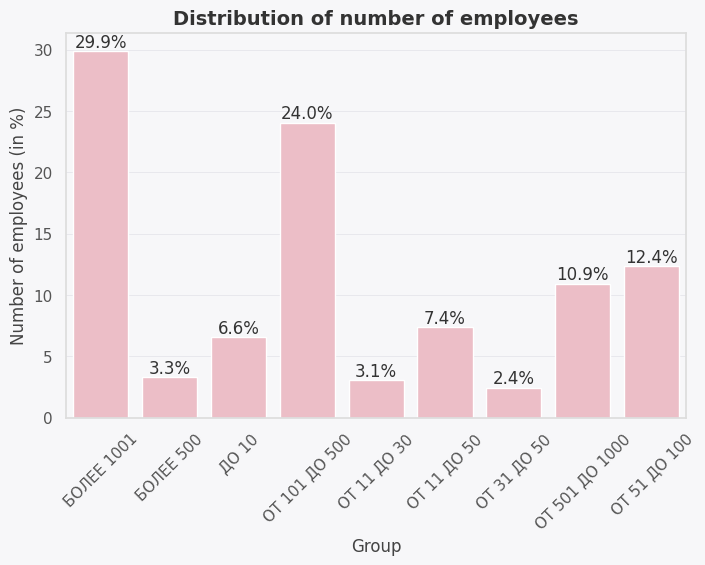

In [80]:
plt.figure(figsize=(8, 5))

values = data['employee_count_nm'].value_counts(dropna=True, normalize=True).sort_index().values * 100
categories = data['employee_count_nm'].value_counts(dropna=True, normalize=True).sort_index().index

ax = sns.barplot(
    x=categories,
    y=values
)

plt.title('Distribution of number of employees')
plt.xlabel('Group')
plt.ylabel('Number of employees (in %)')
plt.xticks(rotation=45)

# подписи над столбцами
for i, v in enumerate(values):
    ax.text(
        i,
        v,
        f'{v:.1f}%',
        ha='center',
        va='bottom'
    )

plt.savefig('employee_count_nm%%.png', dpi=300, bbox_inches='tight')
plt.show()

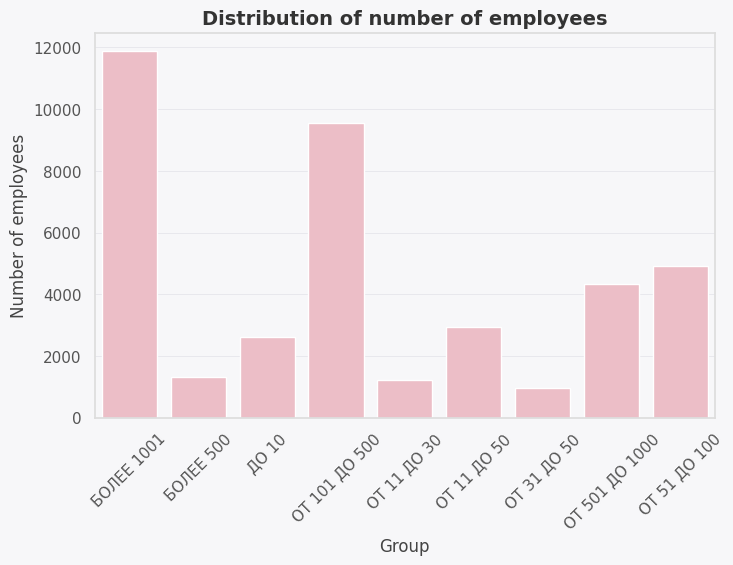

In [81]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x=data['employee_count_nm'].value_counts().sort_index().index,
    y=data['employee_count_nm'].value_counts().sort_index().values
)

plt.title('Distribution of number of employees')
plt.xlabel('Group')
plt.ylabel('Number of employees')
plt.xticks(rotation=45)

plt.savefig('employee_count_nm.png', dpi=300, bbox_inches='tight')
plt.show()

In [82]:
data[data['target'] == 0]['employee_count_nm'].value_counts().sort_index()

employee_count_nm
БОЛЕЕ 1001        11397
БОЛЕЕ 500          1273
ДО 10              2425
ОТ 101 ДО 500      9036
ОТ 11 ДО 30        1138
ОТ 11 ДО 50        2744
ОТ 31 ДО 50         892
ОТ 501 ДО 1000     4146
ОТ 51 ДО 100       4639
Name: count, dtype: int64

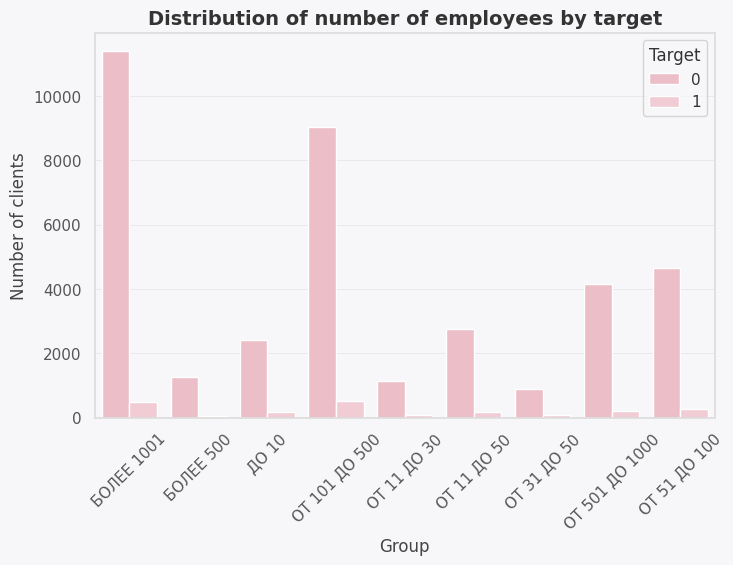

In [83]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x='employee_count_nm',
    hue='target',
    order=data['employee_count_nm'].value_counts().sort_index().index
)

plt.title('Distribution of number of employees by target')
plt.xlabel('Group')
plt.ylabel('Number of clients')
plt.xticks(rotation=45)
plt.legend(title='Target')

plt.savefig('employee_count_nm_by_target.png', dpi=300, bbox_inches='tight')
plt.show()


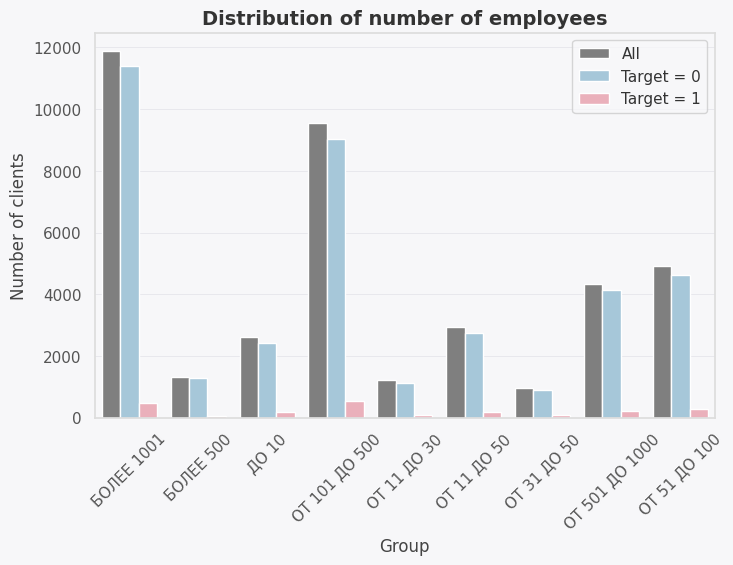

In [84]:
# считаем количества
total = data['employee_count_nm'].value_counts().sort_index()
target_0 = data[data['target'] == 0]['employee_count_nm'].value_counts().sort_index()
target_1 = data[data['target'] == 1]['employee_count_nm'].value_counts().sort_index()

palette = {
    'All': '#7f7f7f',        # нейтральный серый
    'Target = 0': '#9ecae1', # мягкий голубой
    'Target = 1': '#f4a6b5'  # мягкий розовый
}

# объединяем в один датафрейм
plot_df = pd.DataFrame({
    'All': total,
    'Target = 0': target_0,
    'Target = 1': target_1
}).fillna(0).reset_index()

plot_df = plot_df.melt(
    id_vars='employee_count_nm',
    var_name='Group',
    value_name='Count'
)

# рисуем
plt.figure(figsize=(8, 5))

sns.barplot(
    data=plot_df,
    x='employee_count_nm',
    y='Count',
    hue='Group',
    palette=palette
)

plt.title('Distribution of number of employees')
plt.xlabel('Group')
plt.ylabel('Number of clients')
plt.xticks(rotation=45)
plt.legend(title='')

plt.savefig('employee_count_nm_total_0_1.png', dpi=300, bbox_inches='tight')
plt.show()

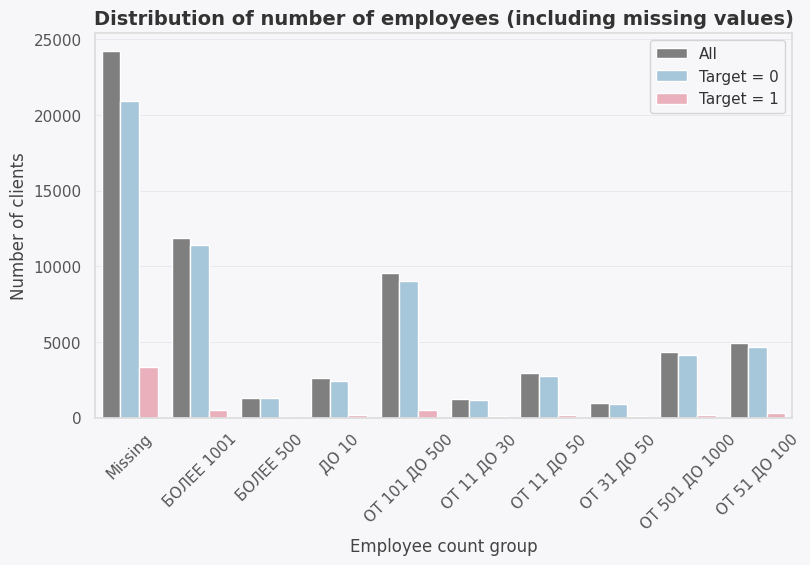

In [85]:
# создаём временную копию признака
emp = data['employee_count_nm'].fillna('Missing')

# считаем количества
total = emp.value_counts().sort_index()
target_0 = emp[data['target'] == 0].value_counts().sort_index()
target_1 = emp[data['target'] == 1].value_counts().sort_index()

palette = {
    'All': '#7f7f7f',        # нейтральный серый
    'Target = 0': '#9ecae1', # мягкий голубой
    'Target = 1': '#f4a6b5'  # мягкий розовый
}

# объединяем в один датафрейм
plot_df = pd.DataFrame({
    'All': total,
    'Target = 0': target_0,
    'Target = 1': target_1
}).fillna(0).reset_index()

plot_df = plot_df.rename(columns={'index': 'employee_count_nm'})

plot_df = plot_df.melt(
    id_vars='employee_count_nm',
    var_name='Group',
    value_name='Count'
)

# рисуем
plt.figure(figsize=(9, 5))

sns.barplot(
    data=plot_df,
    x='employee_count_nm',
    y='Count',
    hue='Group',
    palette=palette
)

plt.title('Distribution of number of employees (including missing values)')
plt.xlabel('Employee count group')
plt.ylabel('Number of clients')
plt.xticks(rotation=45)
plt.legend(title='')

plt.savefig('employee_count_nm_total_0_1_with_missing.png', dpi=300, bbox_inches='tight')
plt.show()


In [86]:
data['employee_count_nm'] = data['employee_count_nm'].fillna('Missing')

In [87]:
data

,user_id,target,time,report,employee_count_nm,bankemplstatus,customer_age,is_young,employee_count_missing
0,3,0,77,2,ОТ 101 ДО 500,0,3,0,0
1,13,0,86,6,ОТ 501 ДО 1000,0,2,0,0
2,37,0,89,5,БОЛЕЕ 1001,0,2,0,0
3,41,0,57,1,ОТ 101 ДО 500,0,2,0,0
4,42,0,84,12,ДО 10,0,3,0,0
...,...,...,...,...,...,...,...,...,...
63995,561824,0,91,12,Missing,0,0,1,1
63996,562043,0,75,12,Missing,0,2,0,1
63997,562312,0,91,12,Missing,0,0,1,1
63998,562721,0,29,12,Missing,0,2,0,1


In [88]:
mapping = {
    # малые
    'ДО 10': 'ДО 10',

    # 11–50 (объединяем всё)
    'ОТ 11 ДО 30': 'ОТ 11 ДО 50',
    'ОТ 31 ДО 50': 'ОТ 11 ДО 50',
    'ОТ 11 ДО 50': 'ОТ 11 ДО 50',

    # 51–100
    'ОТ 51 ДО 100': 'ОТ 51 ДО 100',

    # 101–500
    'ОТ 101 ДО 500': 'ОТ 101 ДО 500',

    # >500 (объединяем всё крупное)
    'ОТ 501 ДО 1000': 'БОЛЕЕ 500',
    'БОЛЕЕ 1001': 'БОЛЕЕ 500',
    'БОЛЕЕ 500': 'БОЛЕЕ 500'
}


In [89]:
data['employee_count_clean'] = (
    data['employee_count_nm']
    .map(mapping)
    .fillna('Missing')
)

In [90]:
data['employee_count_clean'].value_counts()

employee_count_clean
Missing          24223
БОЛЕЕ 500        17557
ОТ 101 ДО 500     9561
ОТ 11 ДО 50       5130
ОТ 51 ДО 100      4917
ДО 10             2612
Name: count, dtype: int64

In [91]:
order = [
    'Missing',
    'ДО 10',
    'ОТ 11 ДО 50',
    'ОТ 51 ДО 100',
    'ОТ 101 ДО 500',
    'БОЛЕЕ 500'
]

data['employee_count_clean'] = pd.Categorical(
    data['employee_count_clean'],
    categories=order,
    ordered=True
)


##  transactions

In [92]:
transactions

,user_id,mcc_code,currency_rk,transaction_amt,transaction_dttm
0,3,3,1,-183.883957,2022-01-28 12:05:33
1,3,3,1,-3206.437012,2022-01-28 12:52:30
2,3,16,1,-153866.890625,2022-02-16 14:45:56
3,3,56,1,-15144.601562,2022-03-09 19:58:29
4,3,0,1,5297.908691,2022-03-12 18:11:31
...,...,...,...,...,...
13075018,562740,155,1,-2484.366211,2023-03-20 11:52:09
13075019,562740,9,1,-187.658463,2023-03-20 12:10:22
13075020,562740,1,1,-891.933350,2023-03-20 15:53:37
13075021,562740,13,1,-464.467316,2023-03-20 15:54:49


* user_id – ID клиента банка
* mcc_code — mcc код транзакции
* currency_rk – валюта транзакции
* transaction_dttm – дата и время совершения операции
* transaction_amt – сумма в валюте транзакции

In [93]:
transactions

,user_id,mcc_code,currency_rk,transaction_amt,transaction_dttm
0,3,3,1,-183.883957,2022-01-28 12:05:33
1,3,3,1,-3206.437012,2022-01-28 12:52:30
2,3,16,1,-153866.890625,2022-02-16 14:45:56
3,3,56,1,-15144.601562,2022-03-09 19:58:29
4,3,0,1,5297.908691,2022-03-12 18:11:31
...,...,...,...,...,...
13075018,562740,155,1,-2484.366211,2023-03-20 11:52:09
13075019,562740,9,1,-187.658463,2023-03-20 12:10:22
13075020,562740,1,1,-891.933350,2023-03-20 15:53:37
13075021,562740,13,1,-464.467316,2023-03-20 15:54:49


In [94]:
tx_target = transactions.merge(data[['user_id', 'target']], on='user_id',how='inner')

In [95]:
currency_target_dist = (tx_target.groupby(['target', 'currency_rk']).size().reset_index(name='count'))


currency_target_dist

,target,currency_rk,count
0,0,0,217549
1,0,1,7875318
2,0,2,861
3,0,3,1069
4,1,0,31384
5,1,1,612265
6,1,2,379
7,1,3,127


In [96]:
transactions.currency_rk.value_counts()

currency_rk
1    12701022
0      370455
3        1795
2        1751
Name: count, dtype: int64

In [97]:
data

,user_id,target,time,report,employee_count_nm,bankemplstatus,customer_age,is_young,employee_count_missing,employee_count_clean
0,3,0,77,2,ОТ 101 ДО 500,0,3,0,0,ОТ 101 ДО 500
1,13,0,86,6,ОТ 501 ДО 1000,0,2,0,0,БОЛЕЕ 500
2,37,0,89,5,БОЛЕЕ 1001,0,2,0,0,БОЛЕЕ 500
3,41,0,57,1,ОТ 101 ДО 500,0,2,0,0,ОТ 101 ДО 500
4,42,0,84,12,ДО 10,0,3,0,0,ДО 10
...,...,...,...,...,...,...,...,...,...,...
63995,561824,0,91,12,Missing,0,0,1,1,Missing
63996,562043,0,75,12,Missing,0,2,0,1,Missing
63997,562312,0,91,12,Missing,0,0,1,1,Missing
63998,562721,0,29,12,Missing,0,2,0,1,Missing


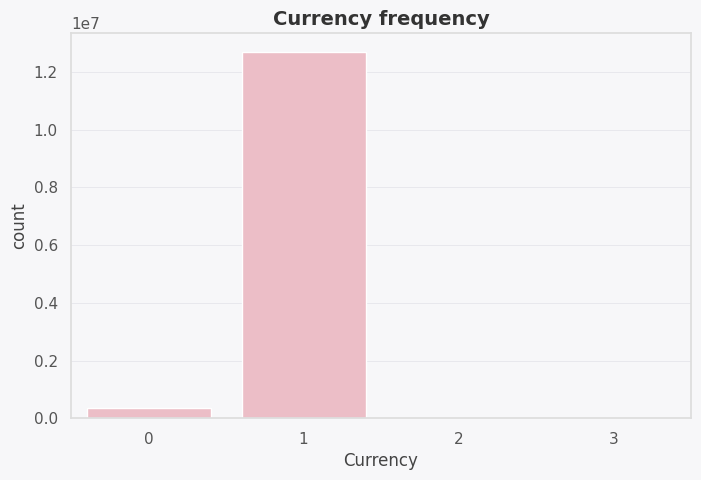

In [98]:
plt.figure(figsize=(8, 5))
sns.barplot(transactions.currency_rk.value_counts())

plt.title('Currency frequency')
plt.xlabel('Currency')


plt.savefig('currency.png', dpi=300, bbox_inches='tight')
plt.show()

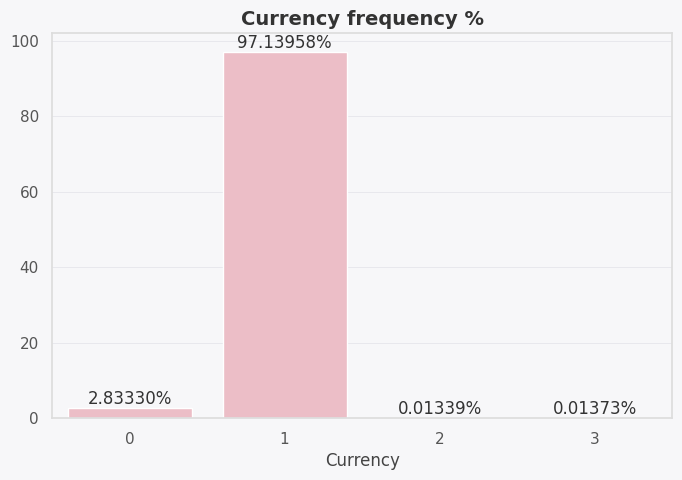

In [99]:
plt.figure(figsize=(8, 5))

values = transactions.currency_rk.value_counts(normalize=True).sort_index().values * 100
categories = transactions.currency_rk.value_counts(normalize=True).sort_index().index

ax = sns.barplot(
    x=categories,
    y=values
)

plt.title('Currency frequency %')
plt.xlabel('Currency')

# подписи над столбцами
for i, v in enumerate(values):
    ax.text(
        i,
        v,
        f'{v:.5f}%',
        ha='center',
        va='bottom'
    )

plt.savefig('currency%.png', dpi=300, bbox_inches='tight')
plt.show()

In [100]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13075023 entries, 0 to 13075022
Data columns (total 5 columns):
 #   Column            Dtype  
---  ------            -----  
 0   user_id           int64  
 1   mcc_code          int64  
 2   currency_rk       int64  
 3   transaction_amt   float64
 4   transaction_dttm  object 
dtypes: float64(1), int64(3), object(1)
memory usage: 498.8+ MB


In [101]:
transactions['user_id'].nunique()

96000

In [102]:
transactions.groupby('user_id').size().describe()

count    96000.000000
mean       136.198156
std        148.584868
min         11.000000
25%         35.000000
50%         82.000000
75%        186.000000
max       1497.000000
dtype: float64

In [103]:
trns_user = transactions.groupby('user_id').size()

In [104]:
trns_user

user_id
3          11
9          90
13         22
37        315
41         16
         ... 
562043     37
562205    151
562312     56
562721     85
562740    497
Length: 96000, dtype: int64

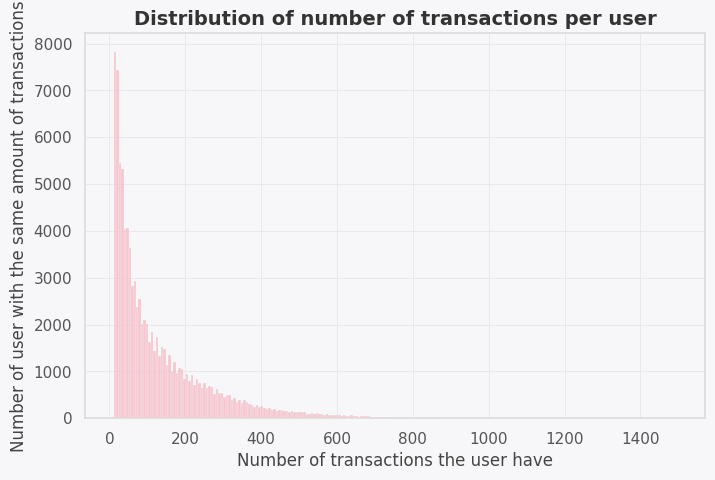

In [105]:
plt.figure(figsize=(8, 5))
sns.histplot(x = trns_user)

plt.title('Distribution of number of transactions per user')
plt.xlabel('Number of transactions the user have')
plt.ylabel('Number of user with the same amount of transactions')

plt.savefig('trnsct_per_user.png', dpi=300, bbox_inches='tight')
plt.show()

In [106]:
trns_user.describe()

count    96000.000000
mean       136.198156
std        148.584868
min         11.000000
25%         35.000000
50%         82.000000
75%        186.000000
max       1497.000000
dtype: float64

In [107]:
transactions.groupby('user_id').size().nlargest(15)

user_id
233591    1497
122632    1488
134327    1486
18628     1483
147739    1479
54506     1478
193686    1472
506564    1466
193770    1461
438289    1447
180313    1445
40726     1444
417122    1437
41075     1434
107291    1433
dtype: int64

In [108]:
transactions.groupby('user_id').size().nsmallest(15)

user_id
3       11
326     11
330     11
1548    11
1621    11
1730    11
1822    11
2160    11
2767    11
3182    11
3260    11
3359    11
3931    11
4290    11
4541    11
dtype: int64

In [109]:
data[data['user_id'].isin([233591, 122632, 134327, 18628, 147739])]

,user_id,target,time,report,employee_count_nm,bankemplstatus,customer_age,is_young,employee_count_missing,employee_count_clean
2171,18628,0,91,7,БОЛЕЕ 500,0,1,0,0,БОЛЕЕ 500
14326,122632,1,91,1,ДО 10,0,1,0,0,ДО 10
17320,147739,0,91,6,ОТ 501 ДО 1000,0,2,0,0,БОЛЕЕ 500
26895,233591,0,91,12,ДО 10,0,1,0,0,ДО 10


In [110]:
transactions[transactions['user_id'] == 100]

,user_id,mcc_code,currency_rk,transaction_amt,transaction_dttm
3855,100,0,1,86.123459,2022-08-27 09:25:22
3856,100,0,1,88.637466,2022-08-27 10:07:12
3857,100,3,1,-94.843559,2022-09-09 13:21:50
3858,100,0,1,105.806625,2022-09-09 13:24:13
3859,100,3,1,-92.507896,2022-09-09 14:16:31
3860,100,0,1,106.332329,2022-09-09 14:55:40
3861,100,0,1,90.729172,2022-09-19 09:50:48
3862,100,0,1,-995.125610,2022-09-27 17:15:00
3863,100,0,1,-2119.127686,2022-09-27 20:04:23
3864,100,0,1,-207.272049,2022-09-28 10:03:00


In [111]:
data[data['user_id'] == 100]

,user_id,target,time,report,employee_count_nm,bankemplstatus,customer_age,is_young,employee_count_missing,employee_count_clean
18,100,1,41,11,БОЛЕЕ 1001,0,3,0,0,БОЛЕЕ 500


* проверить распределение по валютам (возможно таргет == 0 когда более одной валюты)
* распредление по транзакциям
* коды

* колонки: количество транзакций всего, количество -, количество +, другая валюта, обороты и сумма, как-то представить уникальные коды

In [112]:
transactions['mcc_code'].nunique()

332

In [113]:
transactions.groupby('mcc_code').size()

mcc_code
0       582177
1      4152654
2      1065363
3       719400
4       947720
        ...   
412          9
413         23
424          1
434          1
449          1
Length: 332, dtype: int64

In [114]:
transactions[transactions['mcc_code'] == 424]

,user_id,mcc_code,currency_rk,transaction_amt,transaction_dttm
7129593,281112,424,1,-6337.882324,2022-12-16 15:19:36


In [115]:
data[data['user_id']==281112]

,user_id,target,time,report,employee_count_nm,bankemplstatus,customer_age,is_young,employee_count_missing,employee_count_clean
32346,281112,0,91,12,Missing,0,2,0,1,Missing


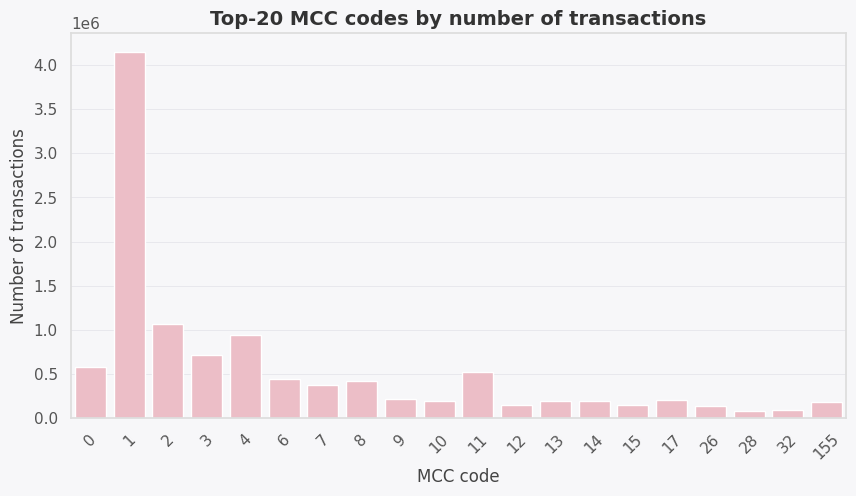

In [116]:
mcc_counts = transactions.groupby('mcc_code').size()
top_mcc = mcc_counts.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 5))

sns.barplot(x=top_mcc.index,y=top_mcc.values)

plt.title('Top-20 MCC codes by number of transactions')
plt.xlabel('MCC code')
plt.ylabel('Number of transactions')
plt.xticks(rotation=45)

plt.savefig('top20_mcc_code_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

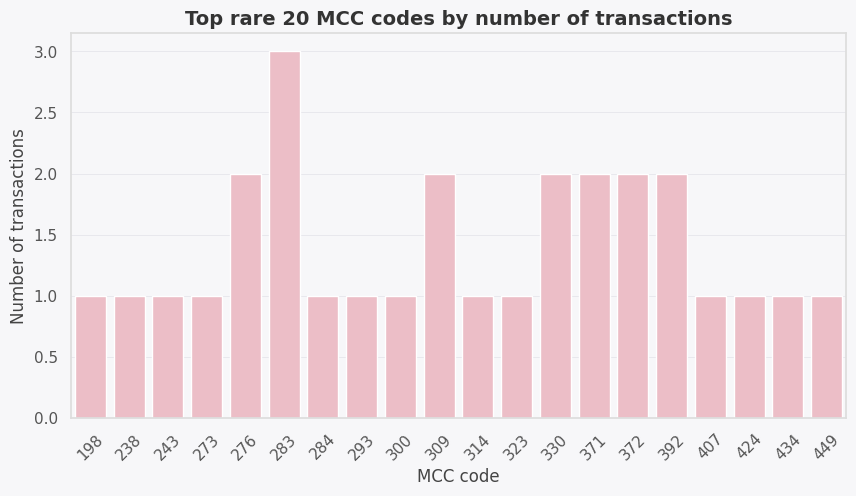

In [117]:
mcc_counts = transactions.groupby('mcc_code').size()
down_mcc = mcc_counts.sort_values(ascending=False).tail(20)

plt.figure(figsize=(10, 5))

sns.barplot(x=down_mcc.index,y=down_mcc.values)

plt.title('Top rare 20 MCC codes by number of transactions')
plt.xlabel('MCC code')
plt.ylabel('Number of transactions')
plt.xticks(rotation=45)

plt.savefig('rare20_mcc_code_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [118]:
import plotly.express as px

mcc_counts = (
    transactions
    .groupby('mcc_code')
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

fig = px.bar(
    mcc_counts,
    x='mcc_code',
    y='count',
    title='Distribution of transactions by MCC code',
    labels={'mcc_code': 'MCC code', 'count': 'Number of transactions'}
)

fig.update_layout(
    xaxis=dict(showticklabels=False),
    width=1200,
    height=450
)

fig.show()

In [119]:
fig = px.bar(
    mcc_counts,
    x='mcc_code',
    y='count',
    title='Distribution of transactions by MCC code (log scale)',
    labels={'mcc_code': 'MCC code', 'count': 'Number of transactions'}
)

fig.update_yaxes(type='log')

fig.update_layout(
    xaxis=dict(showticklabels=False),
    width=1200,
    height=450
)

fig.show()


In [120]:
mcc_counts.median()

mcc_code    166.5
count       747.5
dtype: float64

* распредление по транзакциям частота на юзера СДЕЛАНО
* коды частота СДЕЛАНО
* даты! СДЕЛАНО
* колонка по уникальным кодам СДЕЛАНО в транзакциях

* колонки у клиентов: количество транзакций всего, количество -, количество +, другая валюта, обороты и сумма, как-то представить уникальные коды
* новый дф с групбай по юзерам и там это все

* распредление по сумме транзакций (возможно разбить на + и - , также статистика)
* проверить распределение по валютам (возможно таргет == 0 когда более одной валюты)
* 

In [121]:
print(transactions['transaction_dttm'].max())
print(transactions['transaction_dttm'].min())

2023-03-20 20:59:58
2021-10-20 09:00:00


1 год и 5 месяцев

In [122]:
mcc_counts.describe()

,mcc_code,count
count,332.000000,3.320000e+02
mean,171.719880,3.938260e+04
std,104.803152,2.506828e+05
min,0.000000,1.000000e+00
25%,83.750000,6.300000e+01
50%,166.500000,7.475000e+02
75%,250.250000,7.798250e+03
max,449.000000,4.152654e+06


In [123]:
with pd.option_context('display.float_format', '{:,.0f}'.format):
    print(mcc_counts.describe())

       mcc_code     count
count       332       332
mean        172    39,383
std         105   250,683
min           0         1
25%          84        63
50%         166       748
75%         250     7,798
max         449 4,152,654


In [124]:
mcc_counts['share'] = mcc_counts['count'] / mcc_counts['count'].sum()

In [125]:
with pd.option_context('display.float_format', '{:,.15f}'.format):
    print(mcc_counts.head(10))

    mcc_code    count             share
1          1  4152654 0.317602041694305
2          2  1065363 0.081480774450645
4          4   947720 0.072483237696790
3          3   719400 0.055020935718430
0          0   582177 0.044525887258477
10        11   520796 0.039831363967773
5          6   440264 0.033672139620710
7          8   418128 0.031979140686789
6          7   381862 0.029205455317363
8          9   212977 0.016288843239511


In [126]:
with pd.option_context('display.float_format', '{:,.15f}'.format):
    print(mcc_counts.sort_values(by='count', ascending=True).head(10))

     mcc_code  count             share
331       449      1 0.000000076481701
330       434      1 0.000000076481701
329       424      1 0.000000076481701
326       407      1 0.000000076481701
300       314      1 0.000000076481701
288       300      1 0.000000076481701
276       284      1 0.000000076481701
197       198      1 0.000000076481701
267       273      1 0.000000076481701
305       323      1 0.000000076481701


In [127]:
mcc_counts['cum_share'] = mcc_counts['share'].cumsum()

In [128]:
mcc_counts.head(10)

,mcc_code,count,share,cum_share
1,1,4152654,0.317602,0.317602
2,2,1065363,0.081481,0.399083
4,4,947720,0.072483,0.471566
3,3,719400,0.055021,0.526587
0,0,582177,0.044526,0.571113
10,11,520796,0.039831,0.610944
5,6,440264,0.033672,0.644616
7,8,418128,0.031979,0.676596
6,7,381862,0.029205,0.705801
8,9,212977,0.016289,0.722090


In [129]:
mcc_counts[mcc_counts['cum_share'] <= 0.95].shape

(54, 4)

In [130]:
frequent_mcc = mcc_counts[mcc_counts['cum_share'] <= 0.95].index
transactions['mcc_is_rare'] = (~transactions['mcc_code'].isin(frequent_mcc)).astype(int)

In [131]:
transactions.head()

,user_id,mcc_code,currency_rk,transaction_amt,transaction_dttm,mcc_is_rare
0,3,3,1,-183.883957,2022-01-28 12:05:33,0
1,3,3,1,-3206.437012,2022-01-28 12:52:30,0
2,3,16,1,-153866.890625,2022-02-16 14:45:56,0
3,3,56,1,-15144.601562,2022-03-09 19:58:29,0
4,3,0,1,5297.908691,2022-03-12 18:11:31,0


* распредление по транзакциям частота на юзера СДЕЛАНО
* коды частота СДЕЛАНО
* даты! СДЕЛАНО
* колонка по уникальным кодам СДЕЛАНО в транзакциях
---
* колонки у клиентов: количество транзакций всего, количество -, количество +, другая валюта, обороты и сумма, как-то представить уникальные коды, бинараная колонка для уникальной валюты ? подумать возможно она не нужна
* новый дф с групбай по юзерам и там это все
---
* распредление по сумме транзакций (возможно разбить на + и - , также статистика)
* проверить распределение по валютам (возможно таргет == 0 когда более одной валюты)
* расходы и доходы по мсс кодам

---
---

In [132]:
transactions.groupby('currency_rk')['transaction_amt'].mean()

currency_rk
0     112.999091
1   -1059.803398
2   -3441.433003
3   -4460.333650
Name: transaction_amt, dtype: float64

In [133]:
result = (transactions.assign(operation_type=np.where(transactions['transaction_amt'] < 0,'expense', 'income'))
          .groupby(['currency_rk', 'operation_type'])['transaction_amt'].describe())

result

count          mean           std  \
currency_rk operation_type                                           
0           expense           294482.0  -2420.882149   9253.953164   
            income             75973.0   9934.678046  23158.649775   
1           expense         12076289.0  -1776.680280   7835.308157   
            income            624733.0  12797.656349  28427.183670   
2           expense             1605.0  -7253.367452  21977.438345   
            income               146.0  38463.736795  62182.383857   
3           expense             1617.0  -8557.678790  20868.024745   
            income               178.0  32761.054498  49971.615233   

                                      min          25%           50%  \
currency_rk operation_type                                             
0           expense        -213059.359375 -1146.315918   -412.272736   
            income               0.838302   561.180115   2257.084229   
1           expense        -231368.421875  -914.770752   -345.494598   
            income               0.909036   835.461304   3211.826416   
2           expense        -199901.093750 -3136.524170   -798.078430   
            income              36.931274  1863.327545  10576.258301   
3           expense        -217052.796875 -5792.433105  -1604.538208   
            income               6.086504  2412.791077  10807.622070   

                                     75%            max  
currency_rk operation_type                               
0           expense          -161.008526      -0.920293  
            income           8747.108398  327229.937500  
1           expense          -139.530624      -0.864891  
            income          10930.034180  352076.812500  
2           expense          -260.831512      -1.238967  
            income          46676.072266  316142.812500  
3           expense          -521.315674      -1.261406  
            income          38764.103516  246085.859375

In [134]:
data

,user_id,target,time,report,employee_count_nm,bankemplstatus,customer_age,is_young,employee_count_missing,employee_count_clean
0,3,0,77,2,ОТ 101 ДО 500,0,3,0,0,ОТ 101 ДО 500
1,13,0,86,6,ОТ 501 ДО 1000,0,2,0,0,БОЛЕЕ 500
2,37,0,89,5,БОЛЕЕ 1001,0,2,0,0,БОЛЕЕ 500
3,41,0,57,1,ОТ 101 ДО 500,0,2,0,0,ОТ 101 ДО 500
4,42,0,84,12,ДО 10,0,3,0,0,ДО 10
...,...,...,...,...,...,...,...,...,...,...
63995,561824,0,91,12,Missing,0,0,1,1,Missing
63996,562043,0,75,12,Missing,0,2,0,1,Missing
63997,562312,0,91,12,Missing,0,0,1,1,Missing
63998,562721,0,29,12,Missing,0,2,0,1,Missing


In [135]:
transactions.head()

,user_id,mcc_code,currency_rk,transaction_amt,transaction_dttm,mcc_is_rare
0,3,3,1,-183.883957,2022-01-28 12:05:33,0
1,3,3,1,-3206.437012,2022-01-28 12:52:30,0
2,3,16,1,-153866.890625,2022-02-16 14:45:56,0
3,3,56,1,-15144.601562,2022-03-09 19:58:29,0
4,3,0,1,5297.908691,2022-03-12 18:11:31,0


In [136]:
user_transactions = (transactions.groupby(['user_id']).agg(main_currency=('currency_rk', lambda x: x.mode().iloc[0]),  main_mcc_code=('mcc_code', lambda x: x.mode().iloc[0])).reset_index())

In [137]:
user_transactions.head()

,user_id,main_currency,main_mcc_code
0,3,1,0
1,9,1,1
2,13,1,3
3,37,1,2
4,41,1,3


In [138]:
rare_mcc_flag = (transactions.groupby(['user_id'])['mcc_is_rare'].max().reset_index().rename(columns={'mcc_is_rare': 'has_rare_mcc'}))

In [139]:
rare_mcc_flag

,user_id,has_rare_mcc
0,3,0
1,9,1
2,13,0
3,37,1
4,41,1
...,...,...
95995,562043,1
95996,562205,1
95997,562312,1
95998,562721,0


In [140]:
user_transactions = user_transactions.merge(rare_mcc_flag, on='user_id', how='left')

In [141]:
user_transactions

,user_id,main_currency,main_mcc_code,has_rare_mcc
0,3,1,0,0
1,9,1,1,1
2,13,1,3,0
3,37,1,2,1
4,41,1,3,1
...,...,...,...,...
95995,562043,1,1,1
95996,562205,1,11,1
95997,562312,1,1,1
95998,562721,1,3,0


In [142]:
user_transactions['has_rare_mcc'].isna().sum()

np.int64(0)

In [143]:
number_of_mcc_codes = transactions.groupby(['user_id'])['mcc_code'].nunique().reset_index().rename(columns={'mcc_code': 'number_mcc_codes'})

In [144]:
user_transactions = user_transactions.merge(number_of_mcc_codes, on='user_id', how='left')
user_transactions['number_mcc_codes'].isna().sum()

np.int64(0)

In [145]:
user_transactions.main_currency.value_counts()

main_currency
1    92899
0     3087
3        7
2        7
Name: count, dtype: int64

In [146]:
number_of_currency = transactions.groupby(['user_id'])['currency_rk'].nunique().reset_index().rename(columns={'currency_rk': 'unique_currency'})

In [147]:
user_transactions = user_transactions.merge(number_of_currency, on='user_id', how='left')
user_transactions['unique_currency'].isna().sum()

np.int64(0)

In [148]:
user_transactions

,user_id,main_currency,main_mcc_code,has_rare_mcc,number_mcc_codes,unique_currency
0,3,1,0,0,4,1
1,9,1,1,1,22,1
2,13,1,3,0,4,2
3,37,1,2,1,28,1
4,41,1,3,1,5,1
...,...,...,...,...,...,...
95995,562043,1,1,1,12,1
95996,562205,1,11,1,15,1
95997,562312,1,1,1,7,1
95998,562721,1,3,0,11,1


In [149]:
user_money_agg = (
    transactions
    .groupby('user_id')
    .agg(
        total_expense=('transaction_amt', lambda x: x[x < 0].sum()),
        mean_expense=('transaction_amt', lambda x: x[x < 0].mean()),
        median_expense=('transaction_amt', lambda x: x[x < 0].median()),

        total_income=('transaction_amt', lambda x: x[x > 0].sum()),
        mean_income=('transaction_amt', lambda x: x[x > 0].mean()),
        median_income=('transaction_amt', lambda x: x[x > 0].median()),
    )
    .reset_index()
)

user_money_agg.head()

,user_id,total_expense,mean_expense,median_expense,total_income,mean_income,median_income
0,3,-172401.813156,-43100.453289,-9175.519287,186108.229797,26586.889971,5386.999023
1,9,-323434.666813,-3593.718520,-840.509674,0.000000,NaN,NaN
2,13,-253484.063477,-18106.004534,-16423.615234,128766.684326,16095.835541,10789.110840
3,37,-342598.388037,-1094.563540,-236.546936,10738.788574,5369.394287,5369.394287
4,41,-108586.614166,-6786.663385,-6328.293701,0.000000,NaN,NaN


In [150]:
user_money_agg[
    ['total_income', 'mean_income', 'median_income',
     'total_expense', 'mean_expense', 'median_expense']
] = user_money_agg[
    ['total_income', 'mean_income', 'median_income',
     'total_expense', 'mean_expense', 'median_expense']
].fillna(0)

In [151]:
user_money_agg.head()

,user_id,total_expense,mean_expense,median_expense,total_income,mean_income,median_income
0,3,-172401.813156,-43100.453289,-9175.519287,186108.229797,26586.889971,5386.999023
1,9,-323434.666813,-3593.718520,-840.509674,0.000000,0.000000,0.000000
2,13,-253484.063477,-18106.004534,-16423.615234,128766.684326,16095.835541,10789.110840
3,37,-342598.388037,-1094.563540,-236.546936,10738.788574,5369.394287,5369.394287
4,41,-108586.614166,-6786.663385,-6328.293701,0.000000,0.000000,0.000000


In [152]:
user_transactions = user_transactions.merge(user_money_agg, on='user_id', how='left')

In [153]:
user_transactions

,user_id,main_currency,main_mcc_code,has_rare_mcc,number_mcc_codes,unique_currency,total_expense,mean_expense,median_expense,total_income,mean_income,median_income
0,3,1,0,0,4,1,-172401.813156,-43100.453289,-9175.519287,186108.229797,26586.889971,5386.999023
1,9,1,1,1,22,1,-323434.666813,-3593.718520,-840.509674,0.000000,0.000000,0.000000
2,13,1,3,0,4,2,-253484.063477,-18106.004534,-16423.615234,128766.684326,16095.835541,10789.110840
3,37,1,2,1,28,1,-342598.388037,-1094.563540,-236.546936,10738.788574,5369.394287,5369.394287
4,41,1,3,1,5,1,-108586.614166,-6786.663385,-6328.293701,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
95995,562043,1,1,1,12,1,-29581.256115,-799.493409,-239.170517,0.000000,0.000000,0.000000
95996,562205,1,11,1,15,1,-42460.814964,-286.897398,-147.575630,1968.906334,656.302111,319.916626
95997,562312,1,1,1,7,1,-18537.821270,-331.032523,-271.973526,0.000000,0.000000,0.000000
95998,562721,1,3,0,11,1,-198395.925579,-3005.998872,-1085.630096,34391.163893,1810.061258,1354.750000


In [154]:
data

,user_id,target,time,report,employee_count_nm,bankemplstatus,customer_age,is_young,employee_count_missing,employee_count_clean
0,3,0,77,2,ОТ 101 ДО 500,0,3,0,0,ОТ 101 ДО 500
1,13,0,86,6,ОТ 501 ДО 1000,0,2,0,0,БОЛЕЕ 500
2,37,0,89,5,БОЛЕЕ 1001,0,2,0,0,БОЛЕЕ 500
3,41,0,57,1,ОТ 101 ДО 500,0,2,0,0,ОТ 101 ДО 500
4,42,0,84,12,ДО 10,0,3,0,0,ДО 10
...,...,...,...,...,...,...,...,...,...,...
63995,561824,0,91,12,Missing,0,0,1,1,Missing
63996,562043,0,75,12,Missing,0,2,0,1,Missing
63997,562312,0,91,12,Missing,0,0,1,1,Missing
63998,562721,0,29,12,Missing,0,2,0,1,Missing


In [155]:
transactions

,user_id,mcc_code,currency_rk,transaction_amt,transaction_dttm,mcc_is_rare
0,3,3,1,-183.883957,2022-01-28 12:05:33,0
1,3,3,1,-3206.437012,2022-01-28 12:52:30,0
2,3,16,1,-153866.890625,2022-02-16 14:45:56,0
3,3,56,1,-15144.601562,2022-03-09 19:58:29,0
4,3,0,1,5297.908691,2022-03-12 18:11:31,0
...,...,...,...,...,...,...
13075018,562740,155,1,-2484.366211,2023-03-20 11:52:09,1
13075019,562740,9,1,-187.658463,2023-03-20 12:10:22,0
13075020,562740,1,1,-891.933350,2023-03-20 15:53:37,0
13075021,562740,13,1,-464.467316,2023-03-20 15:54:49,0


In [156]:
transactions

,user_id,mcc_code,currency_rk,transaction_amt,transaction_dttm,mcc_is_rare
0,3,3,1,-183.883957,2022-01-28 12:05:33,0
1,3,3,1,-3206.437012,2022-01-28 12:52:30,0
2,3,16,1,-153866.890625,2022-02-16 14:45:56,0
3,3,56,1,-15144.601562,2022-03-09 19:58:29,0
4,3,0,1,5297.908691,2022-03-12 18:11:31,0
...,...,...,...,...,...,...
13075018,562740,155,1,-2484.366211,2023-03-20 11:52:09,1
13075019,562740,9,1,-187.658463,2023-03-20 12:10:22,0
13075020,562740,1,1,-891.933350,2023-03-20 15:53:37,0
13075021,562740,13,1,-464.467316,2023-03-20 15:54:49,0


In [157]:
transaction_count = transactions.groupby(['user_id'])['transaction_amt'].count().reset_index().rename(columns={'transaction_amt': 'transaction_count'})

In [158]:
user_transactions = user_transactions.merge(transaction_count, on='user_id', how='left')

In [159]:
user_transactions

,user_id,main_currency,main_mcc_code,has_rare_mcc,number_mcc_codes,unique_currency,total_expense,mean_expense,median_expense,total_income,mean_income,median_income,transaction_count
0,3,1,0,0,4,1,-172401.813156,-43100.453289,-9175.519287,186108.229797,26586.889971,5386.999023,11
1,9,1,1,1,22,1,-323434.666813,-3593.718520,-840.509674,0.000000,0.000000,0.000000,90
2,13,1,3,0,4,2,-253484.063477,-18106.004534,-16423.615234,128766.684326,16095.835541,10789.110840,22
3,37,1,2,1,28,1,-342598.388037,-1094.563540,-236.546936,10738.788574,5369.394287,5369.394287,315
4,41,1,3,1,5,1,-108586.614166,-6786.663385,-6328.293701,0.000000,0.000000,0.000000,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95995,562043,1,1,1,12,1,-29581.256115,-799.493409,-239.170517,0.000000,0.000000,0.000000,37
95996,562205,1,11,1,15,1,-42460.814964,-286.897398,-147.575630,1968.906334,656.302111,319.916626,151
95997,562312,1,1,1,7,1,-18537.821270,-331.032523,-271.973526,0.000000,0.000000,0.000000,56
95998,562721,1,3,0,11,1,-198395.925579,-3005.998872,-1085.630096,34391.163893,1810.061258,1354.750000,85


In [160]:
transactions.groupby(['user_id'])['transaction_amt'].count().reset_index().rename(columns={'transaction_amt': 'transaction_count'})

,user_id,transaction_count
0,3,11
1,9,90
2,13,22
3,37,315
4,41,16
...,...,...
95995,562043,37
95996,562205,151
95997,562312,56
95998,562721,85


In [161]:
# Берём транзакции в основной MCC
main_mcc_sum = (
    transactions
    .merge(user_transactions[['user_id', 'main_mcc_code']], on='user_id')
    .query('mcc_code == main_mcc_code')
    .groupby('user_id')['transaction_amt']
    .sum()
)

# Берём сумму всех транзакций пользователя
total_sum = (
    transactions.groupby('user_id')['transaction_amt']
    .sum()
)

# Доля по сумме
user_transactions['main_mcc_share_sum'] = (
    main_mcc_sum / total_sum
).fillna(0)


In [162]:
user_transactions

,user_id,main_currency,main_mcc_code,has_rare_mcc,number_mcc_codes,unique_currency,total_expense,mean_expense,median_expense,total_income,mean_income,median_income,transaction_count,main_mcc_share_sum
0,3,1,0,0,4,1,-172401.813156,-43100.453289,-9175.519287,186108.229797,26586.889971,5386.999023,11,NaN
1,9,1,1,1,22,1,-323434.666813,-3593.718520,-840.509674,0.000000,0.000000,0.000000,90,NaN
2,13,1,3,0,4,2,-253484.063477,-18106.004534,-16423.615234,128766.684326,16095.835541,10789.110840,22,NaN
3,37,1,2,1,28,1,-342598.388037,-1094.563540,-236.546936,10738.788574,5369.394287,5369.394287,315,13.578183
4,41,1,3,1,5,1,-108586.614166,-6786.663385,-6328.293701,0.000000,0.000000,0.000000,16,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95995,562043,1,1,1,12,1,-29581.256115,-799.493409,-239.170517,0.000000,0.000000,0.000000,37,NaN
95996,562205,1,11,1,15,1,-42460.814964,-286.897398,-147.575630,1968.906334,656.302111,319.916626,151,NaN
95997,562312,1,1,1,7,1,-18537.821270,-331.032523,-271.973526,0.000000,0.000000,0.000000,56,NaN
95998,562721,1,3,0,11,1,-198395.925579,-3005.998872,-1085.630096,34391.163893,1810.061258,1354.750000,85,NaN


In [163]:
print(transactions['transaction_dttm'].min(), 
transactions['transaction_dttm'].max())

2021-10-20 09:00:00 2023-03-20 20:59:58
